# Job Accessibility Pipeline

This notebook computes spatial accessibility to employment using:
- Census tract geometries (pygris)
- LODES employment data
- Multimodal travel times (R5R / r5py network)
- OpenStreetMap + GTFS transport network

Output:
- Job accessibility measures within time thresholds

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
from datetime import datetime, timedelta

import pygris
from pygris.data import get_lodes
from pygris.utils import erase_water
import r5py

## 2. Configuration

In [2]:
YEAR = 2023

In [3]:
CITY = "atlanta"
STATE = "GA"
COUNTIES = [
    "121", # Fulton County
    "089", # DeKalb County
    "067", # Cobb County
    "135", # Gwinnett County
]
OSM_PBF = "../data/city_data/atlanta/georgia-260524.osm.pbf"
GTFS_FILES = ["../data/city_data/atlanta/MARTA.zip"]

In [4]:
# CITY = "new_york"
# STATE = "NY"
# COUNTIES = [
#     "005", # Bronx County
#     "047", # Kings County
#     "061", # Manhattan County
#     "081", # Queens County
# ]
# OSM_PBF = "../data/city_data/new_york/newyork_planet_-74.015_40.55_79c33b50.osm.pbf"
# GTFS_FILES = ["../data/city_data/new_york/gtfs_subway.zip"]

In [5]:
# CITY = "denver"
# STATE = "CO"
# COUNTIES = [
#     "031", # Denver County
#     "005", # Arapahoe County
#     "059", # Jefferson County
#     "035", # Douglas County
#     "001", # Adams County
# ]
# OSM_PBF = "../data/city_data/denver/colorado-260513.osm.pbf"
# GTFS_FILES = ["../data/city_data/denver/RTD_Denver_Direct_Operated_Commuter_Rail_GTFS.zip", 
#               "../data/city_data/denver/RTD_Denver_Direct_Operated_Light_Rail_GTFS.zip"]

In [6]:
# CITY = "boston"
# STATE = "MA"
# COUNTIES = [
#     "025", # Suffolk County
#     "009", # Essex County
#     "017", # Middlesex County
#     "021"  # Norfolk County
# ]
# OSM_PBF = "../data/city_data/boston/massachusetts-260524.osm.pbf"
# GTFS_FILES = ["../data/city_data/boston/MBTA_GTFS.zip"]

## 3. Load LODES Employment Data

In [7]:
gdf_lodes_blocks = get_lodes(
    state=STATE,
    year=YEAR,
    lodes_type="wac",
    cache=True,
    agg_level="block",
    return_geometry=True
)
gdf_lodes_blocks = gdf_lodes_blocks[
    gdf_lodes_blocks['w_geocode'].astype(str).str[2:5].isin(COUNTIES)
]

# Compute centroids
gdf_lodes_blocks = gdf_lodes_blocks.to_crs(epsg=3857)
gdf_lodes_blocks['centroid'] = gdf_lodes_blocks.geometry.centroid

print(f"LODES blocks: {len(gdf_lodes_blocks)}")

Requesting feature geometry.
Using FIPS code '13' for input 'ga'
LODES blocks: 15553


## 4. Load Census Tracts

In [8]:
gdf_tracts = pygris.tracts(state=STATE, county=COUNTIES, year=YEAR)
gdf_tracts = erase_water(gdf_tracts)


# Compute centroids
gdf_tracts = gdf_tracts.to_crs(epsg=3857)
gdf_tracts['centroid'] = gdf_tracts.geometry.centroid

print(f"Tracts loaded: {len(gdf_tracts)}")

Using FIPS code '13' for input 'GA'
Tracts loaded: 936


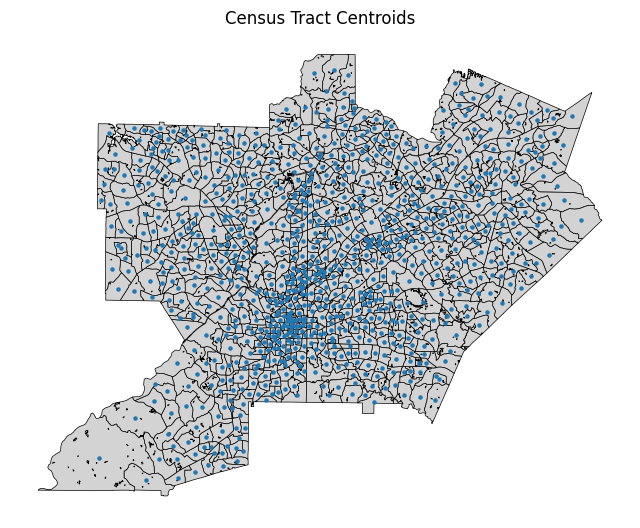

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_tracts.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

gdf_tracts.set_geometry("centroid").plot(
    ax=ax,
    markersize=5,
    legend=True
)

ax.set_title("Census Tract Centroids")
ax.set_axis_off()

plt.show()

## 5. Build Transport Network

In [10]:
transport_network = r5py.TransportNetwork(
    OSM_PBF,
    GTFS_FILES
)

## 6. Origin-Destination Setup

In [11]:
origins = gdf_tracts.copy()
origins.geometry = origins.geometry.centroid
origins["id"] = origins["GEOID"]

destinations = gdf_lodes_blocks.copy()
destinations.geometry = destinations.geometry.centroid
destinations["id"] = destinations["w_geocode"]

## 7. Helper Functions for GTFS time window

In [12]:
def get_gtfs_service_window(gtfs_paths):
    """
    Extract global service window across multiple GTFS feeds.
    Returns: (start_date, end_date) as datetime objects.
    """

    all_starts = []
    all_ends = []

    for path in gtfs_paths:

        with zipfile.ZipFile(path, "r") as z:
            if "calendar.txt" in z.namelist():

                cal = pd.read_csv(z.open("calendar.txt"))

                if "start_date" in cal.columns:
                    all_starts.extend(cal["start_date"].astype(str).tolist())

                if "end_date" in cal.columns:
                    all_ends.extend(cal["end_date"].astype(str).tolist())

            if "calendar_dates.txt" in z.namelist():

                cd = pd.read_csv(z.open("calendar_dates.txt"))

                if "date" in cd.columns:
                    dates = cd["date"].astype(str)
                    all_starts.extend(dates.tolist())
                    all_ends.extend(dates.tolist())

    if not all_starts or not all_ends:
        raise ValueError("No GTFS service dates found.")

    start = min(all_starts)
    end = max(all_ends)

    start_dt = datetime.strptime(start, "%Y%m%d")
    end_dt = datetime.strptime(end, "%Y%m%d")

    return start_dt, end_dt


def get_departure_time(gtfs_paths):
    """
    Pick a valid midpoint departure time within GTFS service window.
    """
    start_dt, end_dt = get_gtfs_service_window(gtfs_paths)

    midpoint = start_dt + (end_dt - start_dt) / 2

    # fixed midday time for stability
    return midpoint.replace(hour=12, minute=0, second=0)

## 8. Travel Time Matrix Computation

In [13]:
travel_time_matrix = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.WALK, r5py.TransportMode.BICYCLE, r5py.TransportMode.TRANSIT],
    departure=get_departure_time(GTFS_FILES),
    max_time=timedelta(minutes=60),
)

## 9. Save / Load Matrix (optional)

In [14]:
# out_dir = Path("intermediate")
# out_dir.mkdir(parents=True, exist_ok=True)

# travel_time_matrix.to_parquet(
#     out_dir / f"{CITY}_travel_time_matrix.parquet"
# )

In [15]:
# travel_time_matrix = pd.read_parquet(f"intermediate/{CITY}_travel_time_matrix.parquet")
# print(travel_time_matrix)

## 10. Job Accessibility Computation

In [ ]:
ttm_jobs = travel_time_matrix.merge(
    gdf_lodes_blocks[['w_geocode', 'C000']],
    left_on='to_id',
    right_on='w_geocode',
    how='left'
)

ttm_jobs['C000'] = ttm_jobs['C000'].fillna(0)

# threshold-based job accessibility
ttm_jobs['jobs_15min'] = np.where(ttm_jobs['travel_time'] <= 15, ttm_jobs['C000'], 0)
ttm_jobs['jobs_30min'] = np.where(ttm_jobs['travel_time'] <= 30, ttm_jobs['C000'], 0)
ttm_jobs['jobs_45min'] = np.where(ttm_jobs['travel_time'] <= 45, ttm_jobs['C000'], 0)
ttm_jobs['jobs_60min'] = np.where(ttm_jobs['travel_time'] <= 60, ttm_jobs['C000'], 0)

accessibility = (
    ttm_jobs.groupby('from_id')[[
        'jobs_15min',
        'jobs_30min',
        'jobs_45min',
        'jobs_60min'
    ]]
    .sum()
    .reset_index()
    .fillna(0)
)

# accessibility = accessibility.fillna(0)

## 11. Merge with Tracts

In [ ]:
threshold_cols = [
    "jobs_15min",
    "jobs_30min",
    "jobs_45min",
    "jobs_60min",
]

gdf_plot = gdf_tracts.merge(
    accessibility,
    left_on="GEOID",
    right_on="from_id",
    how="left"
)

gdf_plot[threshold_cols] = gdf_plot[threshold_cols].fillna(0)

## 12. Visualization

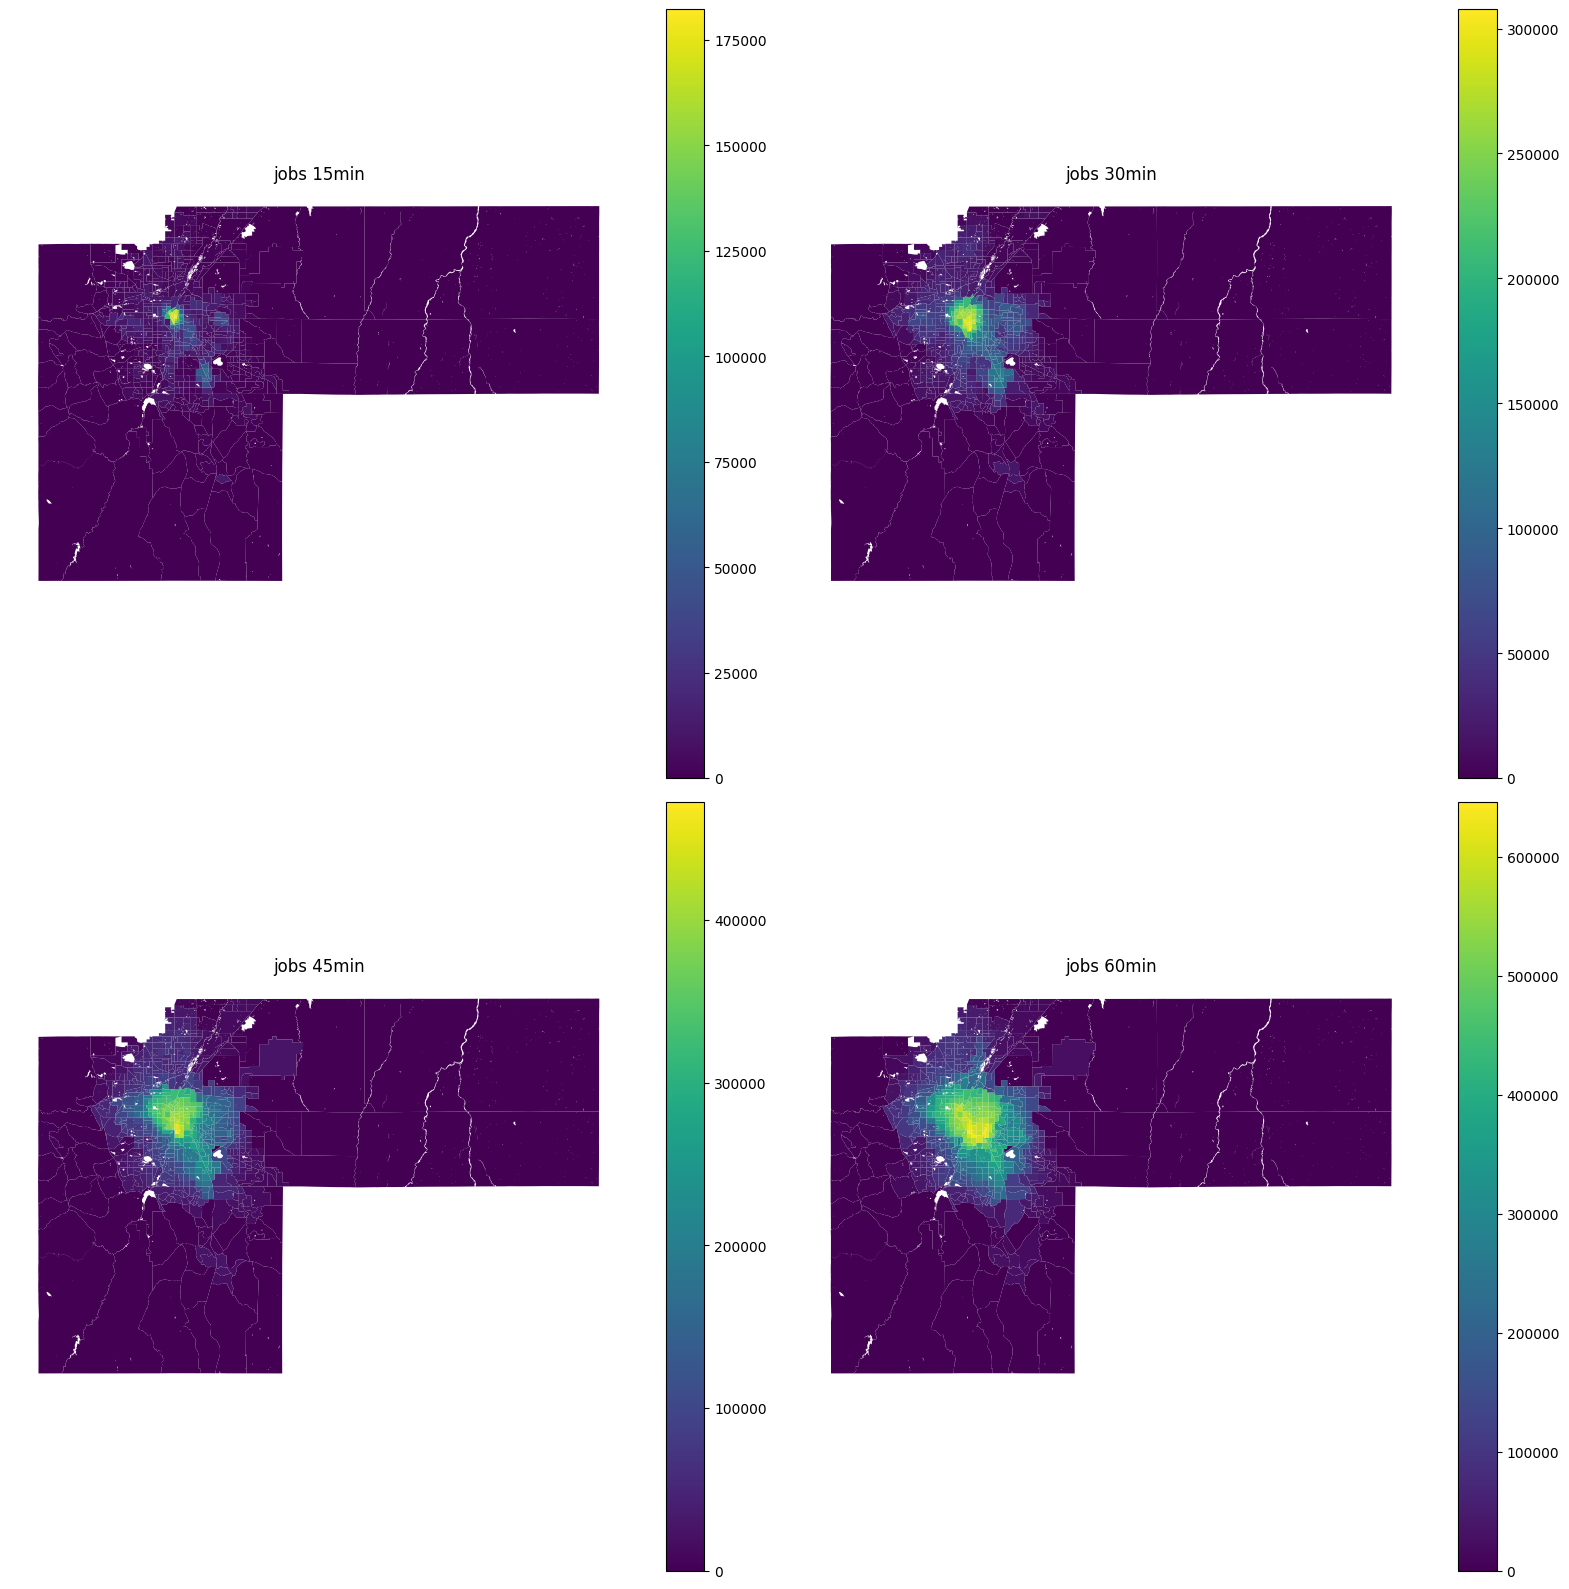

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

axes = axes.flatten()

for ax, col in zip(axes, threshold_cols):
    gdf_plot.plot(
        column=col,
        k=5,
        legend=True,
        ax=ax,
    )

    ax.set_title(col.replace("_", " "))
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## 13. Output (optional)

In [ ]:
# county_str = "-".join(COUNTIES)
# threshold_str = "-".join(map(str, [15, 30, 45, 60]))

# # File name
# filename = (
#     f"accessibility_"
#     f"state-{STATE}_"
#     f"counties-{county_str}_"
#     f"year-{YEAR}_"
#     f"thresholds-{threshold_str}.parquet"
# )

# # Output folder
# output_dir = Path("../data/processed_job_accessibility")
# output_dir.mkdir(parents=True, exist_ok=True)

# filepath = output_dir / filename
# accessibility.to_parquet(filepath, index=False)

# print(filepath)